In [5]:
import csv
import os
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

# Run from the repository or results directory, or set QUICKSILVER_REPO_ROOT.
_repo_candidates = [Path(os.environ['QUICKSILVER_REPO_ROOT']).expanduser()] if os.environ.get('QUICKSILVER_REPO_ROOT') else [Path.cwd(), *Path.cwd().parents]
ROOT = next((path.resolve() for path in _repo_candidates
             if (path / 'scripts/yoked_codes/run_all_workloads.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Run this notebook from the repository, or set QUICKSILVER_REPO_ROOT.')
RESULTS_DIR = Path(os.environ.get('QUICKSILVER_RESULTS_DIR', ROOT / 'results')).expanduser().resolve()
PLOT_DIR = Path(os.environ.get('QUICKSILVER_PLOT_DIR', RESULTS_DIR)).expanduser().resolve()


BENCHMARK_PLOT_ORDER = [
    'bose_hubbard_q',
    'chromium_q_prep',
    'ethylene_q_prep',
    'chromium_q_sel',
    'ethylene_q_sel',
    'bose_hubbard_t',
    'chromium_t',
    'ethylene_t',
    'shor_rsa24',
    'grover_3sat',
]

BENCHMARK_NAME_ALIASES = {
    'bose_hub_q': 'bose_hubbard_q',
    'bose_hub_t': 'bose_hubbard_t',
    'chrom_q_prep': 'chromium_q_prep',
    'chrom_q_sel': 'chromium_q_sel',
    'chrom_t': 'chromium_t',
    'ethyl_q_prep': 'ethylene_q_prep',
    'ethyl_q_sel': 'ethylene_q_sel',
    'ethyl_t': 'ethylene_t',
    'chromium_q_prepare': 'chromium_q_prep',
    'chromium_q_select': 'chromium_q_sel',
    'ethylene_q_prepare': 'ethylene_q_prep',
    'ethylene_q_select': 'ethylene_q_sel',
    'ethylene_oxide_q_prepare': 'ethylene_q_prep',
    'ethylene_oxide_q_select': 'ethylene_q_sel',
    'ethylene_oxide_t': 'ethylene_t',
}

BENCHMARK_PLOT_ORDER_INDEX = {
    benchmark: index for index, benchmark in enumerate(BENCHMARK_PLOT_ORDER)
}

def load_rows(path):
    with open(path, newline='') as f:
        rows = list(csv.DictReader(f))
    return [
        row for row in rows
        if row.get('benchmark') not in (None, '', 'benchmark')
    ]


def to_float(value):
    if value in ('', None):
        return None
    return float(value)


def to_int(value):
    if value in ('', None):
        return None
    return int(float(value))

def canonical_benchmark_name(name):
    return BENCHMARK_NAME_ALIASES.get(name, name)


def benchmark_plot_label(name):
    return canonical_benchmark_name(name)


def sort_rows_by_benchmark_order(rows):
    return sorted(
        rows,
        key=lambda row: (
            BENCHMARK_PLOT_ORDER_INDEX.get(
                canonical_benchmark_name(row.get('benchmark')),
                len(BENCHMARK_PLOT_ORDER),
            ),
            canonical_benchmark_name(row.get('benchmark')),
        ),
    )


def apply_readable_y_grid(ax):
    ax.grid(axis='y', linewidth=0.9, color='0.75', alpha=0.9)


Per-benchmark speedups:
{'Benchmark': 'bose_hubbard_q', 'Cache': 4.2018, 'Prefetch': 5.211, 'Ideal': 5.9633}
{'Benchmark': 'chromium_q_prep', 'Cache': 5.5361, 'Prefetch': 6.5155, 'Ideal': 6.5773}
{'Benchmark': 'ethylene_q_prep', 'Cache': 4.4286, 'Prefetch': 5.4365, 'Ideal': 5.6667}
{'Benchmark': 'chromium_q_sel', 'Cache': 1.3636, 'Prefetch': 4.7273, 'Ideal': 12.5455}
{'Benchmark': 'ethylene_q_sel', 'Cache': 4.0, 'Prefetch': 6.0, 'Ideal': 12.4118}
{'Benchmark': 'bose_hubbard_t', 'Cache': 3.0854, 'Prefetch': 3.1957, 'Ideal': 3.2064}
{'Benchmark': 'chromium_t', 'Cache': 1.4058, 'Prefetch': 3.3188, 'Ideal': 7.4203}
{'Benchmark': 'ethylene_t', 'Cache': 3.6509, 'Prefetch': 3.8868, 'Ideal': 3.8868}
{'Benchmark': 'shor_rsa24', 'Cache': 2.009, 'Prefetch': 3.2262, 'Ideal': 4.1222}
{'Benchmark': 'grover_3sat', 'Cache': 1.7609, 'Prefetch': 2.5815, 'Ideal': 2.8261}
GMean speedups: {'Cache': 2.8171, 'Prefetch': 4.2215, 'Ideal': 5.7168}


(<Figure size 1200x240 with 1 Axes>, <Axes: ylabel='Speedup'>)

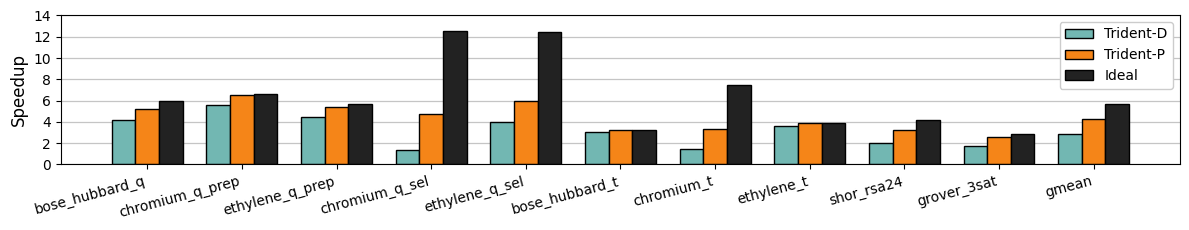

In [92]:
def plot_ipc_c4_i8_relative_speedups(csv_path=None, figsize=(12, 2.4), output_path=None):
    """
    Plot grouped bars for each benchmark showing:
    - Cache RRI speedup over baseline
    - Prefetch LRU speedup over baseline
    - Ideal memory speedup over baseline
    Includes an additional x-axis group labeled 'gmean'.
    """
    if csv_path is None:
        candidates = [
            RESULTS_DIR / 'main_results.csv',
        ]
        csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if csv_path is None:
            raise FileNotFoundError('Could not find main_results.csv')
    else:
        csv_path = Path(csv_path)
    if output_path is None:
        output_path = PLOT_DIR / 'ipc_c4_i8_relative_speedups.pdf'
    else:
        output_path = Path(output_path)

    rows = sort_rows_by_benchmark_order(load_rows(csv_path))

    benchmarks = []
    cache_rri_speedups = []
    prefetch_lru_speedups = []
    ideal_speedups = []

    for row in rows:
        benchmark = benchmark_plot_label(row['benchmark'])
        baseline = to_float(row['baseline_ipc'])
        cache_rri = to_float(row['cache_rri_ipc'])
        prefetch_lru = to_float(row['prefetch_lru_ipc'])
        ideal = to_float(row['ideal_ipc'])

        # Skip benchmarks with missing baseline
        if baseline is None or baseline == 0.0:
            continue

        benchmarks.append(benchmark)
        cache_rri_speedups.append((cache_rri / baseline) if cache_rri is not None else None)
        prefetch_lru_speedups.append((prefetch_lru / baseline) if prefetch_lru is not None else None)
        ideal_speedups.append((ideal / baseline) if ideal is not None else None)

    if not benchmarks:
        raise ValueError('No valid benchmarks found in CSV')

    def _geometric_mean(values):
        values = [value for value in values if value is not None and value > 0]
        if not values:
            return None
        import math
        return math.exp(sum(math.log(value) for value in values) / len(values))

    gmean_cache = _geometric_mean(cache_rri_speedups)
    gmean_prefetch = _geometric_mean(prefetch_lru_speedups)
    gmean_ideal = _geometric_mean(ideal_speedups)

    benchmarks_with_gmean = benchmarks + ['gmean']
    cache_rri_values = cache_rri_speedups + [gmean_cache]
    prefetch_lru_values = prefetch_lru_speedups + [gmean_prefetch]
    ideal_values = ideal_speedups + [gmean_ideal]

    fig, ax = plt.subplots(figsize=figsize)
    ax.tick_params(axis='y', labelsize=10)
    x = list(range(len(benchmarks_with_gmean)))
    width = 0.25

    colors = {
        'cache_rri': '#72B7B2',
        'prefetch_lru': '#F58518',
        'ideal': '#222222',
    }
    edge_colour = 'k'

    # Plot cache RRI
    cache_rri_heights = [0 if v is None else v for v in cache_rri_values]
    ax.bar([xi - width for xi in x], cache_rri_heights, width=width, label='Trident-D', color=colors['cache_rri'], edgecolor=edge_colour)

    # Plot prefetch LRU
    prefetch_lru_heights = [0 if v is None else v for v in prefetch_lru_values]
    ax.bar(x, prefetch_lru_heights, width=width, label='Trident-P', color=colors['prefetch_lru'], edgecolor=edge_colour)

    # Plot ideal memory
    ideal_heights = [0 if v is None else v for v in ideal_values]
    ax.bar([xi + width for xi in x], ideal_heights, width=width, label='Ideal', color=colors['ideal'], edgecolor=edge_colour)

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks_with_gmean, fontsize=10, rotation=15, ha='right')
    ax.set_ylabel('Speedup', fontsize=12)
    apply_readable_y_grid(ax)
    ax.yaxis.set_major_locator(plt.MultipleLocator(2))
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', frameon=True, fontsize=10, framealpha=1.0)
    ax.margins(y=0.12)
    plt.tight_layout()

    benchmark_speedups = []
    for benchmark, cache_value, prefetch_value, ideal_value in zip(
        benchmarks, cache_rri_speedups, prefetch_lru_speedups, ideal_speedups
    ):
        benchmark_speedups.append({
            'Benchmark': benchmark,
            'Cache': None if cache_value is None else round(cache_value, 4),
            'Prefetch': None if prefetch_value is None else round(prefetch_value, 4),
            'Ideal': None if ideal_value is None else round(ideal_value, 4),
        })

    gmean_print = {
        'Cache': None if gmean_cache is None else round(gmean_cache, 4),
        'Prefetch': None if gmean_prefetch is None else round(gmean_prefetch, 4),
        'Ideal': None if gmean_ideal is None else round(gmean_ideal, 4),
    }
    print('Per-benchmark speedups:')
    for row in benchmark_speedups:
        print(row)
    print('GMean speedups:', gmean_print)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    return fig, ax

plot_ipc_c4_i8_relative_speedups()


GMean speedups: {'Trident-D': 2.8171, 'Trident-P': 4.2215, 'Ideal': 5.7168}
Arithmetic mean Trident-D verification latency (cycles): 41.3535
Arithmetic mean Trident-P verification latency (cycles): 14.362

Average load breakdown across benchmarks (% of total loads):
  Trident-D: 2D cold=21.23%, 1D waited=0.0%, 1D already verified=78.77%
  Trident-P: 2D cold=0.0%, 1D waited=8.98%, 1D already verified=91.02%


(<Figure size 1200x480 with 2 Axes>,
 array([<Axes: ylabel='Speedup'>,
        <Axes: ylabel='Mean Verification\nLatency (cycles)'>], dtype=object))

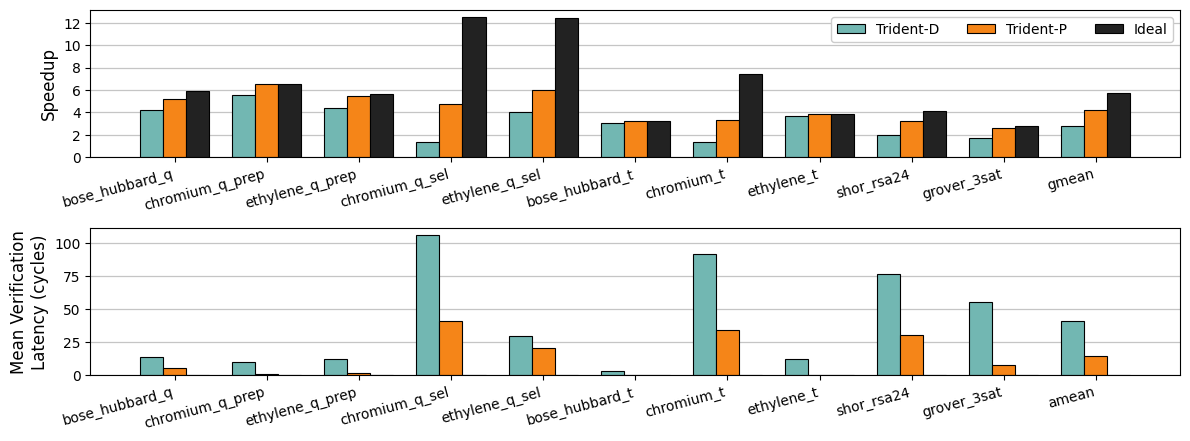

In [2]:
READINESS_LATENCY_CSV = RESULTS_DIR / 'readiness_latency.csv'

def weighted_average_readiness_latency(row, prefix):
    loads_2d = to_int(row.get(f'{prefix}_loads_2d_cold_reached_non_clifford_ready')) or 0
    loads_1d_waited = to_int(row.get(f'{prefix}_loads_1d_waited_for_verification')) or 0
    loads_1d_already_verified = to_int(row.get(f'{prefix}_loads_1d_already_verified')) or 0

    total_loads = loads_2d + loads_1d_waited + loads_1d_already_verified
    if total_loads == 0:
        return None

    avg_2d_delay = to_float(row.get(f'{prefix}_avg_delay_2d_cold_non_clifford_ready_cycles'))
    avg_1d_delay = to_float(row.get(f'{prefix}_avg_delay_1d_non_clifford_ready_cycles'))

    weighted_delay = 0.0
    if loads_2d:
        if avg_2d_delay is None:
            return None
        weighted_delay += avg_2d_delay * loads_2d
    if loads_1d_waited:
        if avg_1d_delay is None:
            return None
        weighted_delay += avg_1d_delay * loads_1d_waited

    return weighted_delay / total_loads


def average_non_null(values):
    valid = [value for value in values if value is not None]
    if not valid:
        return None
    return sum(valid) / len(valid)


def display_readiness_latency(csv_path=None, speedup_csv_path=None, figsize=(12, 4.8), output_path=None):
    if csv_path is None:
        csv_path = READINESS_LATENCY_CSV
    else:
        csv_path = Path(csv_path)
    if speedup_csv_path is None:
        candidates = [
            RESULTS_DIR / 'main_results.csv',
        ]
        speedup_csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if speedup_csv_path is None:
            raise FileNotFoundError('Could not find main_results.csv')
    else:
        speedup_csv_path = Path(speedup_csv_path)

    if output_path is None:
        output_path = PLOT_DIR / 'ipc_speedups_and_readiness_latency_by_benchmark.pdf'
    else:
        output_path = Path(output_path)

    speedup_rows = sort_rows_by_benchmark_order(load_rows(speedup_csv_path))
    speedup_benchmarks = []
    cache_rri_speedups = []
    prefetch_lru_speedups = []
    ideal_speedups = []
    for row in speedup_rows:
        benchmark = benchmark_plot_label(row['benchmark'])
        baseline = to_float(row.get('baseline_ipc'))
        cache_rri = to_float(row.get('cache_rri_ipc'))
        prefetch_lru = to_float(row.get('prefetch_lru_ipc'))
        ideal = to_float(row.get('ideal_ipc'))
        if baseline in (None, 0.0):
            continue

        speedup_benchmarks.append(benchmark)
        cache_rri_speedups.append(None if cache_rri is None else cache_rri / baseline)
        prefetch_lru_speedups.append(None if prefetch_lru is None else prefetch_lru / baseline)
        ideal_speedups.append(None if ideal is None else ideal / baseline)

    if not speedup_benchmarks:
        raise ValueError('No valid baseline IPC rows found in main_results.csv')

    def _geometric_mean(values):
        values = [value for value in values if value is not None and value > 0]
        if not values:
            return None
        import math
        return math.exp(sum(math.log(value) for value in values) / len(values))

    gmean_cache = _geometric_mean(cache_rri_speedups)
    gmean_prefetch = _geometric_mean(prefetch_lru_speedups)
    gmean_ideal = _geometric_mean(ideal_speedups)
    speedup_benchmarks_with_gmean = speedup_benchmarks + ['gmean']
    cache_rri_values = cache_rri_speedups + [gmean_cache]
    prefetch_lru_values = prefetch_lru_speedups + [gmean_prefetch]
    ideal_values = ideal_speedups + [gmean_ideal]

    rows = sort_rows_by_benchmark_order(load_rows(csv_path))
    approaches = ['cache', 'prefetch']
    labels = {
        'cache': 'Trident-D',
        'prefetch': 'Trident-P',
    }
    colors = {
        'cache': '#72B7B2',
        'prefetch': '#F58518',
    }

    benchmarks = [benchmark_plot_label(row['benchmark']) for row in rows]
    values_by_approach = {approach: [] for approach in approaches}
    for row in rows:
        for approach in approaches:
            values_by_approach[approach].append(weighted_average_readiness_latency(row, approach))

    mean_by_approach = {
        approach: average_non_null(values_by_approach[approach])
        for approach in approaches
    }

    benchmarks_with_mean = benchmarks + ['amean']
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    speedup_ax, ax = axes

    speedup_x = list(range(len(speedup_benchmarks_with_gmean)))
    speedup_width = 0.25
    speedup_colors = {
        'cache_rri': '#72B7B2',
        'prefetch_lru': '#F58518',
        'ideal': '#222222',
    }
    speedup_ax.tick_params(axis='y', labelsize=10)
    speedup_ax.bar(
        [xi - speedup_width for xi in speedup_x],
        [0 if value is None else value for value in cache_rri_values],
        width=speedup_width,
        label='Trident-D',
        color=speedup_colors['cache_rri'],
        edgecolor='k',
        linewidth=0.8,
    )
    speedup_ax.bar(
        speedup_x,
        [0 if value is None else value for value in prefetch_lru_values],
        width=speedup_width,
        label='Trident-P',
        color=speedup_colors['prefetch_lru'],
        edgecolor='k',
        linewidth=0.8,
    )
    speedup_ax.bar(
        [xi + speedup_width for xi in speedup_x],
        [0 if value is None else value for value in ideal_values],
        width=speedup_width,
        label='Ideal',
        color=speedup_colors['ideal'],
        edgecolor='k',
        linewidth=0.8,
    )
    speedup_ax.set_xticks(speedup_x)
    speedup_ax.set_xticklabels(speedup_benchmarks_with_gmean, fontsize=10, rotation=15, ha='right')
    speedup_ax.set_ylabel('Speedup', fontsize=12)
    speedup_ax.yaxis.set_major_locator(plt.MultipleLocator(2))
    apply_readable_y_grid(speedup_ax)
    speedup_ax.set_axisbelow(True)
    speedup_ax.legend(loc='upper right', frameon=True, fontsize=10, framealpha=1.0, ncol=3)

    ax.tick_params(axis='y', labelsize=10)
    x = list(range(len(benchmarks_with_mean)))
    width = 0.25
    offsets = {
        'cache': -width,
        'prefetch': 0,
    }

    for approach in approaches:
        heights = [
            float('nan') if value is None else value
            for value in (values_by_approach[approach] + [mean_by_approach[approach]])
        ]
        ax.bar(
            [xi + offsets[approach] for xi in x],
            heights,
            width=width,
            label=labels[approach],
            color=colors[approach],
            edgecolor='k',
            linewidth=0.8,
        )
    ax.bar(
        [xi + width for xi in x],
        [0] * len(benchmarks_with_mean),
        width=width,
        color='#222222',
        edgecolor='k',
        linewidth=0.8,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks_with_mean, rotation=15, ha='right', fontsize=10)
    ax.set_ylabel('Mean Verification\nLatency (cycles)', fontsize=12)
    apply_readable_y_grid(ax)
    ax.set_axisbelow(True)

    print('GMean speedups:', {
        'Trident-D': None if gmean_cache is None else round(gmean_cache, 4),
        'Trident-P': None if gmean_prefetch is None else round(gmean_prefetch, 4),
        'Ideal': None if gmean_ideal is None else round(gmean_ideal, 4),
    })
    print('Arithmetic mean Trident-D verification latency (cycles):', None if mean_by_approach['cache'] is None else round(mean_by_approach['cache'], 4))
    print('Arithmetic mean Trident-P verification latency (cycles):', None if mean_by_approach['prefetch'] is None else round(mean_by_approach['prefetch'], 4))

    # Compute average load-type breakdown as % of total_loads across all benchmarks
    load_keys = ['loads_2d', 'loads_1d_waited', 'loads_1d_already_verified']
    col_names = {
        'loads_2d': 'loads_2d_cold_reached_non_clifford_ready',
        'loads_1d_waited': 'loads_1d_waited_for_verification',
        'loads_1d_already_verified': 'loads_1d_already_verified',
    }
    load_fractions = {approach: {key: [] for key in load_keys} for approach in approaches}
    for row in rows:
        for approach in approaches:
            loads_2d = to_int(row.get(f'{approach}_{col_names["loads_2d"]}')) or 0
            loads_1d_waited = to_int(row.get(f'{approach}_{col_names["loads_1d_waited"]}')) or 0
            loads_1d_already_verified = to_int(row.get(f'{approach}_{col_names["loads_1d_already_verified"]}')) or 0
            total = loads_2d + loads_1d_waited + loads_1d_already_verified
            if total > 0:
                load_fractions[approach]['loads_2d'].append(100.0 * loads_2d / total)
                load_fractions[approach]['loads_1d_waited'].append(100.0 * loads_1d_waited / total)
                load_fractions[approach]['loads_1d_already_verified'].append(100.0 * loads_1d_already_verified / total)

    print()
    print('Average load breakdown across benchmarks (% of total loads):')
    for approach in approaches:
        fracs = load_fractions[approach]
        avg_2d = average_non_null(fracs['loads_2d'])
        avg_1d_waited = average_non_null(fracs['loads_1d_waited'])
        avg_1d_verified = average_non_null(fracs['loads_1d_already_verified'])
        print(f'  {labels[approach]}: 2D cold={None if avg_2d is None else round(avg_2d, 2)}%,'
              f' 1D waited={None if avg_1d_waited is None else round(avg_1d_waited, 2)}%,'
              f' 1D already verified={None if avg_1d_verified is None else round(avg_1d_verified, 2)}%')

    plt.tight_layout(rect=(0, 0, 1, 0.94))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    return fig, axes


display_readiness_latency()


In [ ]:
SENSITIVITY_BLOCK_SIZE_CSV = RESULTS_DIR / 'sensitivity_block_size.csv'

def display_block_size_sensitivity_table(csv_path=None):
    if csv_path is None:
        csv_path = SENSITIVITY_BLOCK_SIZE_CSV
    else:
        csv_path = Path(csv_path)

    rows = load_rows(csv_path)

    def _geometric_mean(values):
        values = [value for value in values if value is not None and value > 0]
        if not values:
            return None
        import math
        return math.exp(sum(math.log(value) for value in values) / len(values))

    density_by_csm = {
        34: 1.53,
        98: 2.28,
        194: 2.76,
        322: 3.08,
        482: 3.35,
    }
    csm_order = [34, 98, 194, 322, 482]

    baseline_ipc_by_benchmark = {}
    for row in rows:
        if row.get('simulation_mode') != 'firstpass' or to_int(row.get('csm')) != 194:
            continue
        ipc = to_float(row.get('ipc'))
        if ipc is None or ipc <= 0:
            continue
        baseline_ipc_by_benchmark[row['benchmark']] = ipc

    speedups_by_mode_and_csm = defaultdict(list)
    for row in rows:
        mode = row.get('simulation_mode')
        csm = to_int(row.get('csm'))
        benchmark = row.get('benchmark')
        if mode not in {'cache', 'prefetch'} or csm not in density_by_csm:
            continue

        baseline_ipc = baseline_ipc_by_benchmark.get(benchmark)
        ipc = to_float(row.get('ipc'))
        if baseline_ipc in (None, 0.0) or ipc is None or ipc <= 0:
            continue

        speedups_by_mode_and_csm[(mode, csm)].append(ipc / baseline_ipc)

    table_rows = []
    for csm in csm_order:
        table_rows.append({
            'Block': str(csm),
            'Relative Density to Surface Code': f"{density_by_csm[csm]:.2f}x",
            'Trident-D Speedup': 'N/A' if _geometric_mean(speedups_by_mode_and_csm[('cache', csm)]) is None else f"{_geometric_mean(speedups_by_mode_and_csm[('cache', csm)]):.3f}x",
            'Trident-P Speedup': 'N/A' if _geometric_mean(speedups_by_mode_and_csm[('prefetch', csm)]) is None else f"{_geometric_mean(speedups_by_mode_and_csm[('prefetch', csm)]):.3f}x",
        })

    from IPython.display import HTML, display

    header = ['Block', 'Relative Density to Surface Code', 'Trident-D Speedup', 'Trident-P Speedup']
    html = ['<table style="border-collapse:collapse;font-size:12px;">']
    html.append('<thead><tr>' + ''.join(f'<th style="border:1px solid #999;padding:6px 10px;text-align:left;">{column}</th>' for column in header) + '</tr></thead>')
    html.append('<tbody>')
    for row in table_rows:
        html.append('<tr>' + ''.join(f'<td style="border:1px solid #999;padding:6px 10px;text-align:left;">{row[column]}</td>' for column in header) + '</tr>')
    html.append('</tbody></table>')
    display(HTML(''.join(html)))
    return table_rows


display_block_size_sensitivity_table()


Block,Relative Density to Surface Code,OPT Speedup,PROMPTLY Speedup
34,1.53x,3.735x,4.584x
98,2.28x,3.121x,4.329x
194,2.76x,2.817x,4.222x
322,3.08x,2.553x,4.008x
482,3.35x,2.367x,3.770x


[{'Block': '34',
  'Relative Density to Surface Code': '1.53x',
  'OPT Speedup': '3.735x',
  'PROMPTLY Speedup': '4.584x'},
 {'Block': '98',
  'Relative Density to Surface Code': '2.28x',
  'OPT Speedup': '3.121x',
  'PROMPTLY Speedup': '4.329x'},
 {'Block': '194',
  'Relative Density to Surface Code': '2.76x',
  'OPT Speedup': '2.817x',
  'PROMPTLY Speedup': '4.222x'},
 {'Block': '322',
  'Relative Density to Surface Code': '3.08x',
  'OPT Speedup': '2.553x',
  'PROMPTLY Speedup': '4.008x'},
 {'Block': '482',
  'Relative Density to Surface Code': '3.35x',
  'OPT Speedup': '2.367x',
  'PROMPTLY Speedup': '3.770x'}]

Buffer-capacity gmean speedups:
  4: Trident-D 2.0749x, Trident-P 3.0868x
  8*: Trident-D 2.8171x, Trident-P 4.2215x
  16: Trident-D 3.7914x, Trident-P 4.9163x
  24: Trident-D 4.3221x, Trident-P 5.5285x


(<Figure size 500x240 with 1 Axes>,
 <Axes: xlabel='L1 Memory Capacity', ylabel='Gmean Speedup'>)

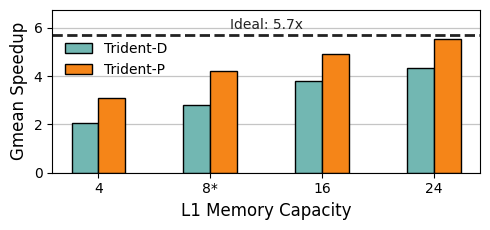

In [100]:
SENSITIVITY_BUFFER_CAPACITY_CSV = RESULTS_DIR / 'sensitivity_buffer_capacity.csv'

def plot_buffer_capacity_gmean_speedups(csv_path=None, figsize=(5, 2.4), output_path=None):
    if csv_path is None:
        csv_path = SENSITIVITY_BUFFER_CAPACITY_CSV
    else:
        csv_path = Path(csv_path)

    if output_path is None:
        output_path = PLOT_DIR / 'buffer_capacity_gmean_speedups.pdf'
    else:
        output_path = Path(output_path)

    with open(csv_path, newline='') as f:
        rows = list(csv.DictReader(f))
    if not rows:
        raise ValueError('Sensitivity CSV is empty')

    def _geometric_mean(values):
        values = [value for value in values if value is not None and value > 0]
        if not values:
            return None
        import math
        return math.exp(sum(math.log(value) for value in values) / len(values))

    benchmark_columns = [key for key in rows[0].keys() if key not in {'intermediate_capacity_i', 'policy'}]

    baseline_row = next((row for row in rows if row['policy'] == 'baseline'), None)
    ideal_row = next((row for row in rows if row['policy'] == 'ideal'), None)
    if baseline_row is None:
        raise ValueError('Could not find baseline row in sensitivity CSV')
    if ideal_row is None:
        raise ValueError('Could not find ideal row in sensitivity CSV')

    baseline_values = {benchmark: to_float(baseline_row.get(benchmark)) for benchmark in benchmark_columns}

    capacity_rows = {}
    for row in rows:
        policy = row['policy']
        if policy in {'baseline', 'ideal'}:
            continue
        capacity = to_int(row['intermediate_capacity_i'])
        capacity_rows.setdefault(capacity, {})[policy] = row

    capacities = sorted(capacity_rows)
    approaches = ['cache_rri', 'prefetch_lru']
    labels = {
        'cache_rri': 'Trident-D',
        'prefetch_lru': 'Trident-P',
        'ideal': 'Ideal',
    }
    colors = {
        'cache_rri': '#72B7B2',
        'prefetch_lru': '#F58518',
        'ideal': '#222222',
    }

    gmean_speedups = {approach: [] for approach in approaches}
    ideal_speedup_values = []

    for capacity in capacities:
        cache_rri_speedups = []
        prefetch_lru_speedups = []
        ideal_speedups = []

        cache_rri_row = capacity_rows[capacity].get('cache_rri')
        prefetch_lru_row = capacity_rows[capacity].get('prefetch_lru')

        for benchmark in benchmark_columns:
            baseline = baseline_values.get(benchmark)
            if baseline in (None, 0.0):
                continue

            cache_rri = to_float(cache_rri_row.get(benchmark)) if cache_rri_row else None
            prefetch_lru = to_float(prefetch_lru_row.get(benchmark)) if prefetch_lru_row else None
            ideal = to_float(ideal_row.get(benchmark))

            if cache_rri is not None and cache_rri > 0:
                cache_rri_speedups.append(cache_rri / baseline)
            if prefetch_lru is not None and prefetch_lru > 0:
                prefetch_lru_speedups.append(prefetch_lru / baseline)
            if ideal is not None and ideal > 0:
                ideal_speedups.append(ideal / baseline)

        gmean_speedups['cache_rri'].append(_geometric_mean(cache_rri_speedups))
        gmean_speedups['prefetch_lru'].append(_geometric_mean(prefetch_lru_speedups))
        ideal_speedup_values.append(_geometric_mean(ideal_speedups))

    ideal_reference = _geometric_mean(ideal_speedup_values)

    fig, ax = plt.subplots(figsize=figsize)
    ax.tick_params(axis='both', labelsize=10)
    x = list(range(len(capacities)))
    width = 0.24
    offsets = {
        'cache_rri': -width / 2,
        'prefetch_lru': width / 2,
    }

    for approach in approaches:
        heights = [float('nan') if value is None else value for value in gmean_speedups[approach]]
        ax.bar(
            [xi + offsets[approach] for xi in x],
            heights,
            width=width,
            label=labels[approach],
            color=colors[approach],
            edgecolor='k',
        )

    if ideal_reference is not None:
        ax.axhline(
            ideal_reference,
            color=colors['ideal'],
            linestyle='--',
            linewidth=2,
        )

    finite_bar_heights = [
        height
        for approach in approaches
        for height in gmean_speedups[approach]
        if height is not None
    ]
    y_reference_values = list(finite_bar_heights)
    if ideal_reference is not None:
        y_reference_values.append(ideal_reference)
    if y_reference_values:
        y_max = max(y_reference_values)
        y_padding = max(0.12, 0.18 * y_max)
        ax.set_ylim(0, y_max + y_padding)

    if ideal_reference is not None and x:
        x_left, x_right = ax.get_xlim()
        x_mid = 0.5 * (x_left + x_right)
        ax.text(
            x_mid,
            ideal_reference + 0.02 * ax.get_ylim()[1],
            f'Ideal: {ideal_reference:.1f}x',
            ha='center',
            va='bottom',
            fontsize=10,
            color=colors['ideal'],
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"{capacity}*" if capacity == 8 else str(capacity) for capacity in capacities], fontsize=10)
    ax.set_xlabel('L1 Memory Capacity', fontsize=12)
    ax.set_ylabel('Gmean Speedup', fontsize=12)
    apply_readable_y_grid(ax)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(0.0, 0.88))
    print('Buffer-capacity gmean speedups:')
    for capacity, opt_speedup, promptly_speedup in zip(capacities, gmean_speedups['cache_rri'], gmean_speedups['prefetch_lru']):
        opt_text = 'N/A' if opt_speedup is None else f"{opt_speedup:.4f}x"
        promptly_text = 'N/A' if promptly_speedup is None else f"{promptly_speedup:.4f}x"
        capacity_label = f"{capacity}*" if capacity == 8 else str(capacity)
        print(f"  {capacity_label}: Trident-D {opt_text}, Trident-P {promptly_text}")
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    return fig, ax


plot_buffer_capacity_gmean_speedups()


Compute-capacity gmean speedups:
  4*: Trident-D 2.8171x, Trident-P 4.2215x, Ideal 5.7168x
  8: Trident-D 2.4413x, Trident-P 3.3679x, Ideal 4.5149x
  12: Trident-D 2.5149x, Trident-P 3.3893x, Ideal 4.5205x
  16: Trident-D 2.3472x, Trident-P 3.1234x, Ideal 4.1444x


(<Figure size 500x240 with 1 Axes>,
 <Axes: xlabel='Compute Subsystem Capacity', ylabel='Gmean Speedup'>)

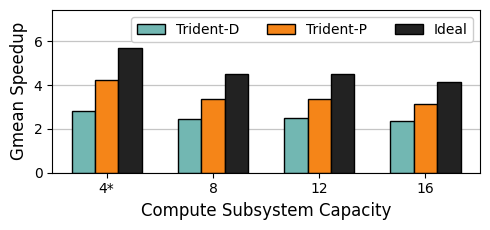

In [104]:
SENSITIVITY_COMPUTE_CSV = RESULTS_DIR / 'sensitivity_compute.csv'

def plot_compute_capacity_gmean_speedups(csv_path=None, figsize=(5, 2.4), output_path=None):
    if csv_path is None:
        csv_path = SENSITIVITY_COMPUTE_CSV
    else:
        csv_path = Path(csv_path)

    if output_path is None:
        output_path = PLOT_DIR / 'compute_capacity_gmean_speedups.pdf'
    else:
        output_path = Path(output_path)

    with open(csv_path, newline='') as f:
        rows = list(csv.DictReader(f))
    if not rows:
        raise ValueError('Sensitivity CSV is empty')

    def _geometric_mean(values):
        values = [value for value in values if value is not None and value > 0]
        if not values:
            return None
        import math
        return math.exp(sum(math.log(value) for value in values) / len(values))

    benchmark_columns = [key for key in rows[0].keys() if key not in {'compute_capacity', 'policy'}]

    rows_by_capacity = defaultdict(dict)
    for row in rows:
        capacity = to_int(row.get('compute_capacity'))
        policy = row.get('policy')
        if capacity is None or not policy:
            continue
        rows_by_capacity[capacity][policy] = row

    capacities = sorted(rows_by_capacity)
    approaches = ['cache_rri', 'prefetch_lru', 'ideal_memory']
    labels = {
        'cache_rri': 'Trident-D',
        'prefetch_lru': 'Trident-P',
        'ideal_memory': 'Ideal',
    }
    colors = {
        'cache_rri': '#72B7B2',
        'prefetch_lru': '#F58518',
        'ideal_memory': '#222222',
    }

    gmean_speedups = {approach: [] for approach in approaches}
    for capacity in capacities:
        capacity_rows = rows_by_capacity[capacity]
        baseline_row = capacity_rows.get('baseline')
        if baseline_row is None:
            raise ValueError(f'Could not find baseline row for compute capacity {capacity}')

        for approach in approaches:
            approach_row = capacity_rows.get(approach)
            speedups = []
            if approach_row is not None:
                for benchmark in benchmark_columns:
                    baseline = to_float(baseline_row.get(benchmark))
                    value = to_float(approach_row.get(benchmark))
                    if baseline in (None, 0.0) or value is None or value <= 0:
                        continue
                    speedups.append(value / baseline)
            gmean_speedups[approach].append(_geometric_mean(speedups))

    fig, ax = plt.subplots(figsize=figsize)
    ax.tick_params(axis='both', labelsize=10)
    x = list(range(len(capacities)))
    width = 0.22
    offsets = {
        'cache_rri': -width,
        'prefetch_lru': 0,
        'ideal_memory': width,
    }

    for approach in approaches:
        heights = [float('nan') if value is None else value for value in gmean_speedups[approach]]
        ax.bar(
            [xi + offsets[approach] for xi in x],
            heights,
            width=width,
            label=labels[approach],
            color=colors[approach],
            edgecolor='k',
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"{capacity}*" if capacity == 4 else str(capacity) for capacity in capacities], fontsize=10)
    ax.set_xlabel('Compute Subsystem Capacity', fontsize=12)
    ax.set_ylabel('Gmean Speedup', fontsize=12)
    apply_readable_y_grid(ax)
    ax.margins(y=0.3)
    ax.set_axisbelow(True)
    ax.legend(frameon=True, fontsize=10, loc='upper right', framealpha=1.0, ncols=3)
    print('Compute-capacity gmean speedups:')
    for capacity, opt_speedup, promptly_speedup, ideal_speedup in zip(
        capacities,
        gmean_speedups['cache_rri'],
        gmean_speedups['prefetch_lru'],
        gmean_speedups['ideal_memory'],
    ):
        opt_text = 'N/A' if opt_speedup is None else f"{opt_speedup:.4f}x"
        promptly_text = 'N/A' if promptly_speedup is None else f"{promptly_speedup:.4f}x"
        ideal_text = 'N/A' if ideal_speedup is None else f"{ideal_speedup:.4f}x"
        capacity_label = f"{capacity}*" if capacity == 4 else str(capacity)
        print(f"  {capacity_label}: Trident-D {opt_text}, Trident-P {promptly_text}, Ideal {ideal_text}")
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    return fig, ax


plot_compute_capacity_gmean_speedups()


Arithmetic mean Baseline stalled cycles (%): 64.3111
Arithmetic mean Trident-D stalled cycles (%): 30.4006
Arithmetic mean Trident-P stalled cycles (%): 19.8682


(<Figure size 500x280 with 1 Axes>, <Axes: ylabel='% of Cycles'>)

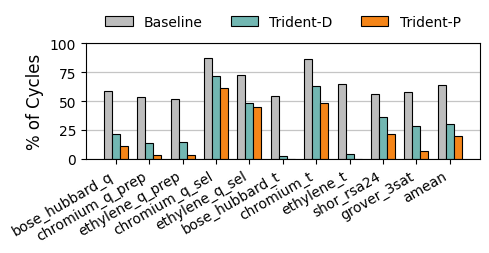

In [116]:
VERIFICATION_STALLS_IMPACT_CSV = RESULTS_DIR / 'verification_stalls_impact.csv'

def plot_non_clifford_readiness_stall_percent(csv_path=None, figsize=(5, 2.8), output_path=None):
    if csv_path is None:
        csv_path = VERIFICATION_STALLS_IMPACT_CSV
    else:
        csv_path = Path(csv_path)

    if output_path is None:
        output_path = PLOT_DIR / 'verification_stall_cycle_percent_by_benchmark.pdf'
    else:
        output_path = Path(output_path)

    rows = sort_rows_by_benchmark_order(load_rows(csv_path))
    if not rows:
        raise ValueError('Verification stalls impact CSV is empty')

    benchmarks = [benchmark_plot_label(row['benchmark']) for row in rows]
    prefixes = ['baseline', 'cache', 'prefetch']
    labels = {
        'baseline': 'Baseline',
        'cache': 'Trident-D',
        'prefetch': 'Trident-P',
    }
    colors = {
        'baseline': '#BDBDBD',
        'cache': '#72B7B2',
        'prefetch': '#F58518',
    }

    values_by_prefix = {prefix: [] for prefix in prefixes}
    for row in rows:
        for prefix in prefixes:
            value = to_float(row.get(f'{prefix}_cycles_stalled_non_clifford_readiness_percent'))
            values_by_prefix[prefix].append(0.0 if value is None else value)

    def arithmetic_mean(values):
        return sum(values) / len(values) if values else 0.0

    mean_by_prefix = {
        prefix: arithmetic_mean(values_by_prefix[prefix])
        for prefix in prefixes
    }
    benchmarks_with_mean = benchmarks + ['amean']

    fig, ax = plt.subplots(figsize=figsize)
    ax.tick_params(axis='y', labelsize=10)
    x = list(range(len(benchmarks_with_mean)))
    width = 0.24
    offsets = {
        'baseline': -width,
        'cache': 0,
        'prefetch': width,
    }

    for prefix in prefixes:
        positions = [xi + offsets[prefix] for xi in x]
        ax.bar(
            positions,
            values_by_prefix[prefix] + [mean_by_prefix[prefix]],
            width=width,
            label=labels[prefix],
            color=colors[prefix],
            edgecolor='k',
            linewidth=0.8,
            zorder=2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks_with_mean, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('% of Cycles', fontsize=12)
    ax.set_ylim(0, 100)
    apply_readable_y_grid(ax)
    ax.set_axisbelow(True)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=10, frameon=False)
    print('Arithmetic mean Baseline stalled cycles (%):', round(mean_by_prefix['baseline'], 4))
    print('Arithmetic mean Trident-D stalled cycles (%):', round(mean_by_prefix['cache'], 4))
    print('Arithmetic mean Trident-P stalled cycles (%):', round(mean_by_prefix['prefetch'], 4))
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    return fig, ax


plot_non_clifford_readiness_stall_percent()


Arithmetic mean LRU hit rate (%): 66.7175
Arithmetic mean OPT hit rate (%): 78.7102
GMean speedups: {'LRU': 2.3252, 'OPT': 2.8171, 'Ideal': 5.7168}


(<Figure size 1200x480 with 2 Axes>,
 array([<Axes: ylabel='Speedup'>, <Axes: ylabel='Hit Rate (%)'>],
       dtype=object))

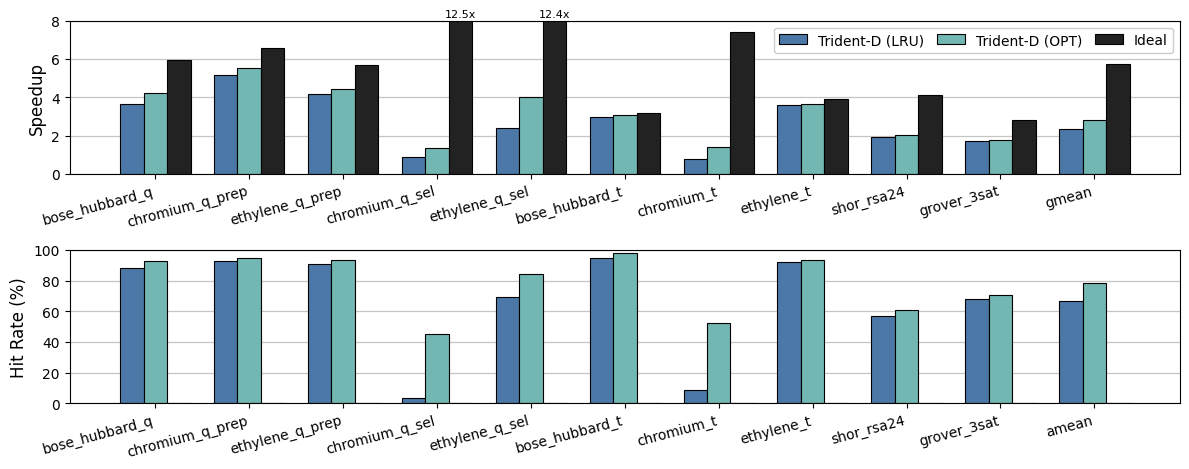

In [115]:
CACHE_PREFETCH_POLICIES_CSV = RESULTS_DIR / 'cache_prefetch_policies.csv'

def plot_cache_compile_hit_rate_by_benchmark(csv_path=None, speedup_csv_path=None, figsize=(12.0, 4.8), output_path=None):
    if csv_path is None:
        csv_path = CACHE_PREFETCH_POLICIES_CSV
    else:
        csv_path = Path(csv_path)
    if speedup_csv_path is None:
        candidates = [
            RESULTS_DIR / 'main_results.csv',
        ]
        speedup_csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if speedup_csv_path is None:
            raise FileNotFoundError('Could not find main_results.csv')
    else:
        speedup_csv_path = Path(speedup_csv_path)

    if output_path is None:
        output_path = PLOT_DIR / 'cache_hit_rate_and_policy_speedups_by_benchmark.pdf'
    else:
        output_path = Path(output_path)

    rows = sort_rows_by_benchmark_order(load_rows(csv_path))
    if not rows:
        raise ValueError('Cache/prefetch policy CSV is empty')

    benchmarks = [benchmark_plot_label(row['benchmark']) for row in rows]
    lru_hit_rates = []
    rri_hit_rates = []
    for row in rows:
        lru_miss_rate = to_float(row.get('lru_miss_rate'))
        rri_miss_rate = to_float(row.get('rri_miss_rate'))
        lru_hit_rates.append(None if lru_miss_rate is None else 100.0 - lru_miss_rate)
        rri_hit_rates.append(None if rri_miss_rate is None else 100.0 - rri_miss_rate)

    arithmetic_mean_lru_hit_rate = average_non_null(lru_hit_rates)
    arithmetic_mean_rri_hit_rate = average_non_null(rri_hit_rates)
    benchmarks_with_mean = benchmarks + ['amean']
    lru_hit_rates_with_mean = lru_hit_rates + [arithmetic_mean_lru_hit_rate]
    rri_hit_rates_with_mean = rri_hit_rates + [arithmetic_mean_rri_hit_rate]
    ideal_hit_rates_with_mean = [0.0] * len(benchmarks_with_mean)

    speedup_rows = sort_rows_by_benchmark_order(load_rows(speedup_csv_path))
    speedup_benchmarks = []
    cache_lru_speedups = []
    cache_rri_speedups = []
    ideal_speedups = []
    for row in speedup_rows:
        baseline = to_float(row.get('baseline_ipc'))
        cache_lru = to_float(row.get('cache_lru_ipc'))
        cache_rri = to_float(row.get('cache_rri_ipc'))
        ideal = to_float(row.get('ideal_ipc'))
        if baseline in (None, 0.0):
            continue

        speedup_benchmarks.append(benchmark_plot_label(row['benchmark']))
        cache_lru_speedups.append(None if cache_lru is None else cache_lru / baseline)
        cache_rri_speedups.append(None if cache_rri is None else cache_rri / baseline)
        ideal_speedups.append(None if ideal is None else ideal / baseline)

    if not speedup_benchmarks:
        raise ValueError('No valid baseline IPC rows found in main_results.csv')

    import math

    def geometric_mean(values):
        valid = [value for value in values if value is not None and value > 0.0]
        if not valid:
            return None
        return math.exp(sum(math.log(value) for value in valid) / len(valid))

    gmean_lru = geometric_mean(cache_lru_speedups)
    gmean_rri = geometric_mean(cache_rri_speedups)
    gmean_ideal = geometric_mean(ideal_speedups)
    speedup_benchmarks_with_gmean = speedup_benchmarks + ['gmean']
    cache_lru_values = cache_lru_speedups + [gmean_lru]
    cache_rri_values = cache_rri_speedups + [gmean_rri]
    ideal_values = ideal_speedups + [gmean_ideal]

    fig, axes = plt.subplots(2, 1, figsize=figsize)
    speedup_ax, hit_ax = axes
    hit_x = list(range(len(benchmarks_with_mean)))
    hit_width = 0.25

    lru_heights = [float('nan') if value is None else value for value in lru_hit_rates_with_mean]
    rri_heights = [float('nan') if value is None else value for value in rri_hit_rates_with_mean]
    ideal_hit_heights = [float('nan') if value is None else value for value in ideal_hit_rates_with_mean]
    hit_ax.tick_params(axis='y', labelsize=10)
    hit_ax.bar(
        [xi - hit_width for xi in hit_x],
        lru_heights,
        width=hit_width,
        label='Trident-D (LRU)',
        color='#4C78A8',
        edgecolor='k',
        linewidth=0.8,
    )
    hit_ax.bar(
        hit_x,
        rri_heights,
        width=hit_width,
        label='Trident-D (OPT)',
        color='#72B7B2',
        edgecolor='k',
        linewidth=0.8,
    )
    hit_ax.bar(
        [xi + hit_width for xi in hit_x],
        ideal_hit_heights,
        width=hit_width,
        label='Ideal',
        color='#222222',
        edgecolor='k',
        linewidth=0.8,
    )
    hit_ax.set_ylabel('Hit Rate (%)', fontsize=12)
    hit_ax.set_ylim(0, 100)
    apply_readable_y_grid(hit_ax)
    hit_ax.set_axisbelow(True)
    hit_ax.set_xticks(hit_x)
    hit_ax.set_xticklabels(benchmarks_with_mean, rotation=15, ha='right', fontsize=10)

    speedup_x = list(range(len(speedup_benchmarks_with_gmean)))
    speedup_width = 0.25
    speedup_colors = {
        'cache_lru': '#4C78A8',
        'cache_rri': '#72B7B2',
        'ideal': '#222222',
    }
    speedup_ax.tick_params(axis='y', labelsize=10)
    speedup_ax.bar(
        [xi - speedup_width for xi in speedup_x],
        [0 if value is None else value for value in cache_lru_values],
        width=speedup_width,
        label='Trident-D (LRU)',
        color=speedup_colors['cache_lru'],
        edgecolor='k',
        linewidth=0.8,
    )
    speedup_ax.bar(
        speedup_x,
        [0 if value is None else value for value in cache_rri_values],
        width=speedup_width,
        label='Trident-D (OPT)',
        color=speedup_colors['cache_rri'],
        edgecolor='k',
        linewidth=0.8,
    )
    speedup_ax.bar(
        [xi + speedup_width for xi in speedup_x],
        [0 if value is None else value for value in ideal_values],
        width=speedup_width,
        label='Ideal',
        color=speedup_colors['ideal'],
        edgecolor='k',
        linewidth=0.8,
    )
    speedup_ax.set_ylabel('Speedup', fontsize=12)
    speedup_ax.set_ylim(0, 8)
    apply_readable_y_grid(speedup_ax)
    speedup_ax.set_axisbelow(True)
    speedup_ax.set_xticks(speedup_x)
    speedup_ax.set_xticklabels(speedup_benchmarks_with_gmean, rotation=15, ha='right', fontsize=10)
    speedup_ax.legend(loc='upper right', frameon=True, framealpha=1.0, fontsize=10, ncol=3, columnspacing=0.9)
    for xi, value in zip(speedup_x, ideal_values):
        if value is not None and value > 8:
            speedup_ax.text(
                xi + speedup_width,
                8.08,
                f'{value:.1f}x',
                ha='center',
                va='bottom',
                fontsize=8,
                color='black',
                clip_on=False,
            )

    print('Arithmetic mean LRU hit rate (%):', None if arithmetic_mean_lru_hit_rate is None else round(arithmetic_mean_lru_hit_rate, 4))
    print('Arithmetic mean OPT hit rate (%):', None if arithmetic_mean_rri_hit_rate is None else round(arithmetic_mean_rri_hit_rate, 4))
    print('GMean speedups:', {
        'LRU': None if gmean_lru is None else round(gmean_lru, 4),
        'OPT': None if gmean_rri is None else round(gmean_rri, 4),
        'Ideal': None if gmean_ideal is None else round(gmean_ideal, 4),
    })
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    return fig, axes


plot_cache_compile_hit_rate_by_benchmark()


Per-benchmark baseline slowdown from ideal:
{'Benchmark': 'bose_hubbard_q', 'Ideal_over_Baseline': 5.9633}
{'Benchmark': 'chromium_q_prep', 'Ideal_over_Baseline': 6.5773}
{'Benchmark': 'ethylene_q_prep', 'Ideal_over_Baseline': 5.6667}
{'Benchmark': 'chromium_q_sel', 'Ideal_over_Baseline': 12.5455}
{'Benchmark': 'ethylene_q_sel', 'Ideal_over_Baseline': 12.4118}
{'Benchmark': 'bose_hubbard_t', 'Ideal_over_Baseline': 3.2064}
{'Benchmark': 'chromium_t', 'Ideal_over_Baseline': 7.4203}
{'Benchmark': 'ethylene_t', 'Ideal_over_Baseline': 3.8868}
{'Benchmark': 'shor_rsa24', 'Ideal_over_Baseline': 4.1222}
{'Benchmark': 'grover_3sat', 'Ideal_over_Baseline': 2.8261}
Geometric mean baseline slowdown from ideal: 5.7168


(<Figure size 500x240 with 1 Axes>, <Axes: ylabel='Speedup'>)

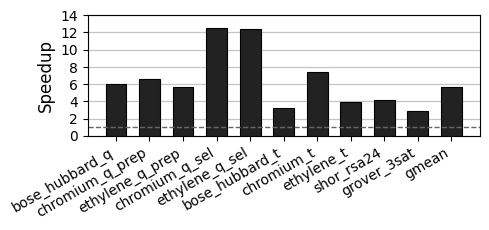

In [87]:
def plot_baseline_slowdown_from_ideal(csv_path=None, figsize=(5.0, 2.4), output_path=None):
    if csv_path is None:
        candidates = [
            RESULTS_DIR / 'main_results.csv',
        ]
        csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
        if csv_path is None:
            raise FileNotFoundError('Could not find main_results.csv')
    else:
        csv_path = Path(csv_path)

    if output_path is None:
        output_path = PLOT_DIR / 'baseline_slowdown_from_ideal.pdf'
    else:
        output_path = Path(output_path)

    rows = sort_rows_by_benchmark_order(load_rows(csv_path))

    benchmarks = []
    slowdowns = []
    for row in rows:
        baseline = to_float(row.get('baseline_ipc'))
        ideal = to_float(row.get('ideal_ipc'))
        if baseline in (None, 0.0) or ideal is None or ideal <= 0.0:
            continue

        benchmarks.append(benchmark_plot_label(row['benchmark']))
        slowdowns.append(ideal / baseline)

    if not slowdowns:
        raise ValueError('No valid baseline/ideal IPC rows found in main_results.csv')

    import math

    gmean_slowdown = math.exp(sum(math.log(value) for value in slowdowns) / len(slowdowns))
    benchmarks_with_gmean = benchmarks + ['gmean']
    slowdowns_with_gmean = slowdowns + [gmean_slowdown]

    fig, ax = plt.subplots(figsize=figsize)
    x = list(range(len(benchmarks_with_gmean)))
    ax.tick_params(axis='y', labelsize=10)
    ax.bar(
        x,
        slowdowns_with_gmean,
        width=0.62,
        color='#222222',
        edgecolor='k',
        linewidth=0.8,
    )
    ax.axhline(1.0, color='0.4', linewidth=1.0, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks_with_gmean, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('Speedup', fontsize=12)
    ax.yaxis.set_major_locator(plt.MultipleLocator(2))
    apply_readable_y_grid(ax)
    ax.set_axisbelow(True)
    ax.margins(y=0.12)
    print('Per-benchmark baseline slowdown from ideal:')
    for benchmark, slowdown in zip(benchmarks, slowdowns):
        print({'Benchmark': benchmark, 'Ideal_over_Baseline': round(slowdown, 4)})
    print('Geometric mean baseline slowdown from ideal:', round(gmean_slowdown, 4))

    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    return fig, ax


plot_baseline_slowdown_from_ideal()


Arithmetic mean prefetch inserted (%): 32.4786
Arithmetic mean 1D already verified within prefetch (%): 91.0214
Arithmetic mean 1D needed verification within prefetch (%): 8.9754
Arithmetic mean 2D needed verification within prefetch (%): 0.0031


((<Figure size 500x240 with 1 Axes>, <Axes: ylabel='% of Loads'>),
 (<Figure size 500x240 with 1 Axes>, <Axes: ylabel='% of Loads'>))

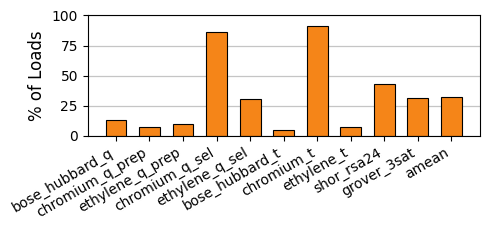

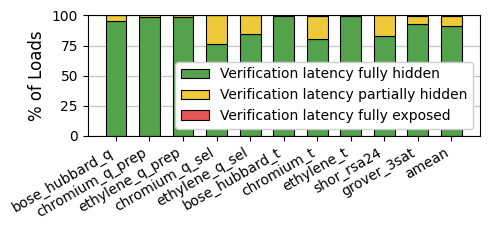

In [19]:
def plot_prefetch_coverage_and_verification_breakdown(
    prefetch_csv_path=None,
    verification_csv_path=None,
    coverage_figsize=(5.0, 2.4),
    breakdown_figsize=(5.0, 2.4),
    coverage_output_path=None,
    breakdown_output_path=None,
):
    if prefetch_csv_path is None:
        prefetch_csv_path = RESULTS_DIR / 'prefetch_percentage.csv'
    else:
        prefetch_csv_path = Path(prefetch_csv_path)

    if verification_csv_path is None:
        verification_csv_path = RESULTS_DIR / 'verification_stalls_impact.csv'
    else:
        verification_csv_path = Path(verification_csv_path)

    if coverage_output_path is None:
        coverage_output_path = PLOT_DIR / 'prefetch_coverage_by_benchmark.pdf'
    else:
        coverage_output_path = Path(coverage_output_path)

    if breakdown_output_path is None:
        breakdown_output_path = PLOT_DIR / 'prefetch_verification_breakdown_by_benchmark.pdf'
    else:
        breakdown_output_path = Path(breakdown_output_path)

    prefetch_rows = sort_rows_by_benchmark_order(load_rows(prefetch_csv_path))
    verification_rows = sort_rows_by_benchmark_order(load_rows(verification_csv_path))

    if not prefetch_rows:
        raise ValueError('Prefetch percentage CSV is empty')
    if not verification_rows:
        raise ValueError('Verification stalls impact CSV is empty')

    verification_by_benchmark = {
        canonical_benchmark_name(row['benchmark']): row
        for row in verification_rows
    }

    benchmarks = []
    pct_prefetch = []
    pct_1d_verified = []
    pct_1d_waited = []
    pct_2d_cold = []

    for row in prefetch_rows:
        canonical_name = canonical_benchmark_name(row['benchmark'])
        vrow = verification_by_benchmark.get(canonical_name)
        if vrow is None:
            continue

        prefetch_pct = to_float(row.get('prefetch_percentage'))
        if prefetch_pct is None:
            continue

        loads_1d_verified = to_float(vrow.get('prefetch_loads_1d_already_verified')) or 0.0
        loads_1d_waited = to_float(vrow.get('prefetch_loads_1d_waited_for_verification')) or 0.0
        loads_2d_cold = to_float(vrow.get('prefetch_loads_2d_cold_reached_non_clifford_ready')) or 0.0
        total_prefetch_loads = loads_1d_verified + loads_1d_waited + loads_2d_cold

        benchmarks.append(benchmark_plot_label(canonical_name))
        pct_prefetch.append(prefetch_pct)

        if total_prefetch_loads > 0:
            pct_1d_verified.append(100.0 * loads_1d_verified / total_prefetch_loads)
            pct_1d_waited.append(100.0 * loads_1d_waited / total_prefetch_loads)
            pct_2d_cold.append(100.0 * loads_2d_cold / total_prefetch_loads)
        else:
            pct_1d_verified.append(0.0)
            pct_1d_waited.append(0.0)
            pct_2d_cold.append(0.0)

    if not benchmarks:
        raise ValueError('No overlapping benchmarks found between the two CSV files')

    avg_prefetch = sum(pct_prefetch) / len(pct_prefetch)
    avg_1d_verified = sum(pct_1d_verified) / len(pct_1d_verified)
    avg_1d_waited = sum(pct_1d_waited) / len(pct_1d_waited)
    avg_2d_cold = sum(pct_2d_cold) / len(pct_2d_cold)

    print('Arithmetic mean prefetch inserted (%):', round(avg_prefetch, 4))
    print('Arithmetic mean 1D already verified within prefetch (%):', round(avg_1d_verified, 4))
    print('Arithmetic mean 1D needed verification within prefetch (%):', round(avg_1d_waited, 4))
    print('Arithmetic mean 2D needed verification within prefetch (%):', round(avg_2d_cold, 4))

    benchmarks_with_mean = benchmarks + ['amean']
    x = list(range(len(benchmarks_with_mean)))
    width = 0.62

    prefetch_with_mean = pct_prefetch + [avg_prefetch]
    verified_with_mean = pct_1d_verified + [avg_1d_verified]
    waited_with_mean = pct_1d_waited + [avg_1d_waited]
    cold_with_mean = pct_2d_cold + [avg_2d_cold]

    coverage_fig, coverage_ax = plt.subplots(figsize=coverage_figsize)
    coverage_ax.tick_params(axis='y', labelsize=10)
    coverage_ax.bar(
        x,
        prefetch_with_mean,
        width=width,
        color='#F58518',
        edgecolor='k',
        linewidth=0.8,
    )
    coverage_ax.set_ylabel('% of Loads', fontsize=12)
    coverage_ax.set_ylim(0, 100)
    coverage_ax.set_xticks(x)
    coverage_ax.set_xticklabels(benchmarks_with_mean, rotation=30, ha='right', fontsize=10)
    apply_readable_y_grid(coverage_ax)
    coverage_ax.set_axisbelow(True)
    coverage_fig.tight_layout()

    breakdown_fig, breakdown_ax = plt.subplots(figsize=breakdown_figsize)
    breakdown_ax.tick_params(axis='y', labelsize=10)
    breakdown_ax.bar(
        x,
        verified_with_mean,
        width=width,
        label='Verification latency fully hidden',
        color='#54A24B',
        edgecolor='k',
        linewidth=0.8,
    )
    breakdown_ax.bar(
        x,
        waited_with_mean,
        width=width,
        bottom=verified_with_mean,
        label='Verification latency partially hidden',
        color='#EECA3B',
        edgecolor='k',
        linewidth=0.8,
    )
    breakdown_ax.bar(
        x,
        cold_with_mean,
        width=width,
        bottom=[a + b for a, b in zip(verified_with_mean, waited_with_mean)],
        label='Verification latency fully exposed',
        color='#E45756',
        edgecolor='k',
        linewidth=0.8,
    )
    breakdown_ax.set_ylabel('% of Loads', fontsize=12)
    breakdown_ax.set_ylim(0, 100)
    breakdown_ax.set_xticks(x)
    breakdown_ax.set_xticklabels(benchmarks_with_mean, rotation=30, ha='right', fontsize=10)
    apply_readable_y_grid(breakdown_ax)
    breakdown_ax.set_axisbelow(True)
    breakdown_ax.legend(loc='lower right', frameon=True, framealpha=1.0, fontsize=10)
    breakdown_fig.tight_layout()

    coverage_output_path.parent.mkdir(parents=True, exist_ok=True)
    coverage_fig.savefig(coverage_output_path, bbox_inches='tight')
    breakdown_output_path.parent.mkdir(parents=True, exist_ok=True)
    breakdown_fig.savefig(breakdown_output_path, bbox_inches='tight')
    return (coverage_fig, coverage_ax), (breakdown_fig, breakdown_ax)


plot_prefetch_coverage_and_verification_breakdown()


In [2]:
# Application fidelity (%). Install the Numbers reader with %pip install numbers-parser.
from html import escape
from math import isfinite
from IPython.display import HTML, display

try:
    from numbers_parser import Document
except ImportError as exc:
    raise ImportError('Run %pip install numbers-parser in this notebook kernel first.') from exc


def table_input_path(filename):
    # Generated CSVs must come from this run; the spreadsheets are static inputs.
    directories = [RESULTS_DIR]
    if filename.endswith('.numbers'):
        directories.append(ROOT / 'results')
    for directory in directories:
        path = directory / filename
        if path.is_file():
            return path
    raise FileNotFoundError(f'Could not find {filename}; pass its path explicitly.')


def load_numbers_rows(path, required_columns):
    document = Document(str(path))
    for sheet in document.sheets:
        for table in sheet.tables:
            values = table.rows(values_only=True)
            if not values or not set(required_columns).issubset(values[0]):
                continue
            # Ignore blank rows and unlabeled summary rows in the Numbers table.
            rows = [dict(zip(values[0], row)) for row in values[1:]]
            return [row for row in rows if row.get('benchmark') not in (None, '', 'benchmark')]
    raise ValueError(f'{path}: no table contains {required_columns}')


def display_percentage_table(rows, columns, caption):
    style = 'border:1px solid #999;padding:6px 10px;text-align:right;'
    html = ['<table style="border-collapse:collapse;font-size:12px;">',
            f'<caption>{escape(caption)}</caption>', '<thead><tr>']
    html += [f'<th style="{style}">{escape(column)}</th>' for column in columns]
    html.append('</tr></thead><tbody>')
    for row in rows:
        html.append('<tr style="font-weight:bold;">' if row['Benchmark'] in ('amean', 'gmean') else '<tr>')
        for column in columns:
            value = row[column]
            text = str(value) if column == 'Benchmark' else ('N/A' if value is None else f'{value:.2f}%')
            html.append(f'<td style="{style}">{escape(text)}</td>')
        html.append('</tr>')
    html.append('</tbody></table>')
    display(HTML(''.join(html)))


def calculate_application_fidelity(csv_path=None, program_cycles_path=None):
    """Apply the spreadsheet error model to the extractor CSV; return raw fidelities."""
    csv_path = table_input_path('logical_qubit_round_error_rates_csm194.csv') if csv_path is None else Path(csv_path)
    program_cycles_path = table_input_path('application_fidelity.csv.numbers') if program_cycles_path is None else Path(program_cycles_path)
    # The extractor CSV does not include the spreadsheet's full-program cycle counts.
    program_rows = load_numbers_rows(program_cycles_path, ['benchmark', 'total_program_cycles'])
    program_cycles = {
        canonical_benchmark_name(row['benchmark']): float(row['total_program_cycles'])
        for row in program_rows
    }
    rows = sort_rows_by_benchmark_order(load_rows(csv_path))
    if not rows:
        raise ValueError(f'No benchmarks found in {csv_path}')

    def nonnegative_number(row, column):
        value = to_float(row.get(column))
        return value if value is not None and isfinite(value) and value >= 0 else None

    code_distance = 25
    compute_error_per_round = 4.0 ** (-code_distance) / 10 * 4
    for row in rows:
        benchmark = canonical_benchmark_name(row['benchmark'])
        if benchmark not in program_cycles:
            raise ValueError(f'Missing total_program_cycles for {benchmark} in {program_cycles_path}')
        full_cycles = program_cycles[benchmark]
        if not isfinite(full_cycles) or full_cycles <= 0:
            raise ValueError(f'Invalid total_program_cycles for {benchmark}: {full_cycles}')
        row['total_program_cycles'] = full_cycles
        for prefix in ('firstpass', 'cache', 'prefetch'):
            cycles = nonnegative_number(row, f'{prefix}_total_simulation_cycles')
            instructions = nonnegative_number(row, f'{prefix}_unrolled_instructions_done')
            cold_rate = nonnegative_number(row, f'{prefix}_cold_storage_error_rate_sum')
            # Baseline has no 1D storage. Trident-P uses its 1D rate (Q), not cold rate (R).
            storage_rate = 0.0 if prefix == 'firstpass' else nonnegative_number(row, f'{prefix}_storage_1d_error_rate')
            if any(value is None for value in (cycles, instructions, cold_rate, storage_rate)) or instructions == 0:
                row[f'{prefix}_total_fidelity'] = None
                continue
            rounds = code_distance * cycles / instructions * full_cycles
            cold_error = 194 * cold_rate * rounds
            storage_error = 8 * storage_rate * rounds
            compute_error = compute_error_per_round * rounds
            row[f'{prefix}_total_fidelity'] = 1 - (cold_error + storage_error + compute_error)
    return rows


application_fidelity_rows = calculate_application_fidelity()
fidelity_columns = {
    'Baseline': 'firstpass_total_fidelity',
    'Trident-D': 'cache_total_fidelity',
    'Trident-P': 'prefetch_total_fidelity',
}
application_fidelity_table = [
    {'Benchmark': benchmark_plot_label(row['benchmark']), **{
        label: None if row[column] is None else 100 * row[column]
        for label, column in fidelity_columns.items()
    }}
    for row in application_fidelity_rows
]
mean_row = {'Benchmark': 'amean'}
for label in fidelity_columns:
    values = [row[label] for row in application_fidelity_table if row[label] is not None]
    mean_row[label] = sum(values) / len(values) if values else None
application_fidelity_table.append(mean_row)
display_percentage_table(application_fidelity_table, ['Benchmark', *fidelity_columns], 'Application fidelity (%)')


Benchmark,Baseline,Trident-D,Trident-P
bose_hubbard_q,90.24%,97.71%,98.14%
chromium_q_prep,97.51%,99.60%,99.64%
ethylene_q_prep,90.41%,97.94%,98.27%
chromium_q_sel,85.75%,89.88%,93.54%
ethylene_q_sel,75.95%,94.12%,95.32%
bose_hubbard_t,97.03%,99.05%,99.08%
chromium_t,97.24%,98.18%,98.32%
ethylene_t,98.55%,99.63%,99.65%
shor_rsa24,99.61%,99.81%,99.86%
grover_3sat,96.83%,98.22%,98.77%


In [3]:
# Space overhead (%). Run the preceding fidelity cell to define the Numbers/table helpers.
from math import exp, log


def calculate_space_overhead(numbers_path=None):
    numbers_path = table_input_path('space_overhead.numbers') if numbers_path is None else Path(numbers_path)
    rows = sort_rows_by_benchmark_order(
        load_numbers_rows(numbers_path, ['benchmark', 'Trident', 'Overhead'])
    )
    if not rows:
        raise ValueError(f'No benchmarks found in {numbers_path}')
    table_rows = []
    for row in rows:
        entry = {'Benchmark': benchmark_plot_label(row['benchmark'])}
        for label, source in (('Trident', 'Trident'), ('Ideal', 'Overhead')):
            ratio = to_float(row.get(source))
            entry[label] = None if ratio is None or not isfinite(ratio) else (ratio - 1) * 100
        table_rows.append(entry)
    # Average the space ratios, then express the geometric mean as an increase.
    mean_row = {'Benchmark': 'gmean'}
    for label, source in (('Trident', 'Trident'), ('Ideal', 'Overhead')):
        ratios = [to_float(row.get(source)) for row in rows]
        ratios = [ratio for ratio in ratios if ratio is not None and isfinite(ratio) and ratio > 0]
        mean_row[label] = (
            (exp(sum(log(ratio) for ratio in ratios) / len(ratios)) - 1) * 100
            if ratios else None
        )
    table_rows.append(mean_row)
    return table_rows


space_overhead_table = calculate_space_overhead()
display_percentage_table(space_overhead_table, ['Benchmark', 'Trident', 'Ideal'], 'Space overhead (%)')


Benchmark,Trident,Ideal
bose_hubbard_q,0.83%,92.69%
chromium_q_prep,9.15%,66.08%
ethylene_q_prep,4.78%,46.97%
bose_hubbard_t,0.83%,89.21%
chromium_t,9.15%,22.07%
ethylene_t,4.78%,23.04%
shor_rsa24,9.15%,12.92%
grover_3sat,1.10%,96.80%
gmean,4.91%,52.79%
